# Seed Averaging — Option B: CV-Based (OOF)

Train CatBoost with S different random seeds, each with full 5-fold CV.
Average OOF predictions across seeds for an honest AUC estimate of the ensemble.
Average test predictions across all S×5 fold models for the submission.

**Why this helps**: each training run has randomness from row subsampling, feature subsampling,
and split tie-breaking. Different seeds explore different regions of the hypothesis space.
Averaging reduces prediction variance without changing bias — a free improvement.

**Option A** (full-data seed averaging, separate notebook) trains each model on 100% of the
training data with no CV splits — typically gives slightly stronger individual models
but cannot directly estimate the ensemble AUC.

## Imports & Data

In [1]:
import numpy as np
import pandas as pd
import subprocess
from pathlib import Path
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score
import catboost as cb
import matplotlib.pyplot as plt


KAGGLE_DATA = Path('/kaggle/input/playground-series-s6e2')
LOCAL_DATA  = Path('data')
DATA_DIR    = KAGGLE_DATA if KAGGLE_DATA.exists() else LOCAL_DATA

def prep(df):
    df = df.copy()
    df.columns = df.columns.str.strip().str.lower().str.replace(r'\s+', '_', regex=True)
    if 'heart_disease' in df.columns:
        df['heart_disease'] = df['heart_disease'].map({'Absence': 0, 'Presence': 1})
    return df

train = prep(pd.read_csv(DATA_DIR / 'train.csv'))
test  = prep(pd.read_csv(DATA_DIR / 'test.csv'))
ss    = pd.read_csv(DATA_DIR / 'sample_submission.csv')

FEATURES     = [c for c in train.columns if c not in ['heart_disease', 'id']]
CAT_FEATURES = ['sex', 'chest_pain_type', 'fbs_over_120', 'ekg_results',
                'exercise_angina', 'slope_of_st', 'number_of_vessels_fluro', 'thallium']

X      = train[FEATURES]
y      = train['heart_disease'].values
X_test = test[FEATURES]

print(f'Train: {X.shape}    Test: {X_test.shape}')

Train: (630000, 13)    Test: (270000, 13)


## Configuration

In [2]:
N_SEEDS = 10        # number of random seeds
N_FOLDS = 5         # folds per seed
SEEDS   = list(range(N_SEEDS))  # 0, 1, 2, ..., 9

# Base model params — same as best single-model CatBoost
BASE_PARAMS = dict(
    iterations=500, learning_rate=0.1, depth=6,
    task_type='GPU', cat_features=CAT_FEATURES,
    verbose=0
    # random_state set per seed in the loop
)

SINGLE_MODEL_AUC = 0.95533  # best single-seed 5-fold CV AUC (reference)

print(f'Seeds: {SEEDS}')
print(f'Total model fits: {N_SEEDS * N_FOLDS}  ({N_SEEDS} seeds × {N_FOLDS} folds)')

Seeds: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]
Total model fits: 50  (10 seeds × 5 folds)


## Seed-Averaged CV Loop

For each seed:
- Create a `StratifiedKFold` with that seed (different fold assignments per seed)
- Set the same seed on `CatBoostClassifier` (different model randomness per seed)
- Collect OOF predictions and test predictions (averaged across folds)

After all seeds:
- Average OOF arrays → single OOF array → compute ensemble AUC
- Average test arrays → submission predictions

In [3]:
oof_per_seed  = np.zeros((N_SEEDS, len(y)))
test_per_seed = np.zeros((N_SEEDS, len(X_test)))
per_seed_auc  = []

for s, seed in enumerate(SEEDS):
    cv = StratifiedKFold(n_splits=N_FOLDS, shuffle=True, random_state=seed)
    oof  = np.zeros(len(y))
    test_folds = np.zeros((N_FOLDS, len(X_test)))

    for fold, (tr_idx, val_idx) in enumerate(cv.split(X, y)):
        m = cb.CatBoostClassifier(**BASE_PARAMS, random_state=seed)
        m.fit(X.iloc[tr_idx], y[tr_idx])
        oof[val_idx]        = m.predict_proba(X.iloc[val_idx])[:, 1]
        test_folds[fold]    = m.predict_proba(X_test)[:, 1]

    seed_auc = roc_auc_score(y, oof)
    per_seed_auc.append(seed_auc)
    oof_per_seed[s]  = oof
    test_per_seed[s] = test_folds.mean(axis=0)  # average across folds

    # Running ensemble AUC (all seeds so far)
    ensemble_oof_so_far = oof_per_seed[:s+1].mean(axis=0)
    ensemble_auc_so_far = roc_auc_score(y, ensemble_oof_so_far)
    print(f'seed={seed:2d}  single_auc={seed_auc:.5f}  '
          f'ensemble_auc({s+1} seeds)={ensemble_auc_so_far:.5f}')

print(f'\nDone. Single-model AUC range: [{min(per_seed_auc):.5f}, {max(per_seed_auc):.5f}]')

seed= 0  single_auc=0.95534  ensemble_auc(1 seeds)=0.95534
seed= 1  single_auc=0.95533  ensemble_auc(2 seeds)=0.95537
seed= 2  single_auc=0.95532  ensemble_auc(3 seeds)=0.95538
seed= 3  single_auc=0.95534  ensemble_auc(4 seeds)=0.95539
seed= 4  single_auc=0.95534  ensemble_auc(5 seeds)=0.95539
seed= 5  single_auc=0.95535  ensemble_auc(6 seeds)=0.95540
seed= 6  single_auc=0.95535  ensemble_auc(7 seeds)=0.95540
seed= 7  single_auc=0.95534  ensemble_auc(8 seeds)=0.95540
seed= 8  single_auc=0.95534  ensemble_auc(9 seeds)=0.95540
seed= 9  single_auc=0.95533  ensemble_auc(10 seeds)=0.95540

Done. Single-model AUC range: [0.95532, 0.95535]


## Results

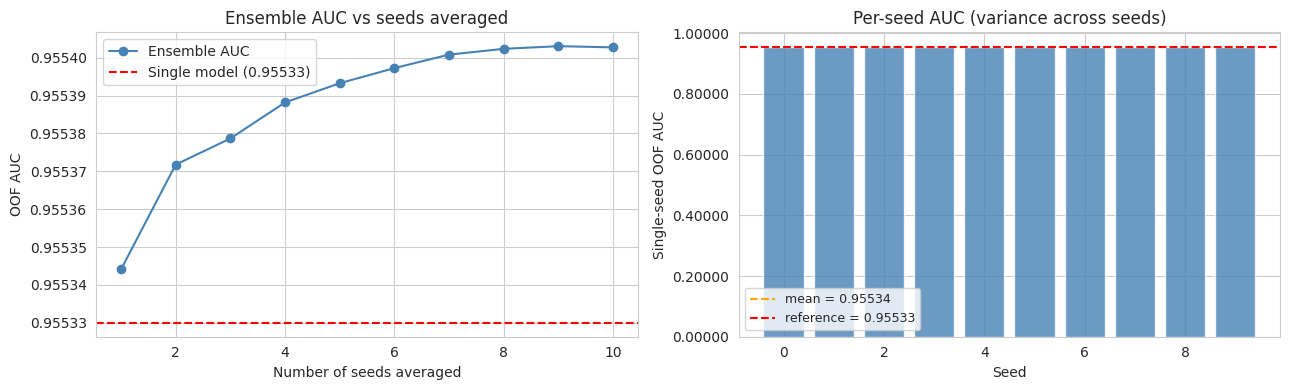

Single-model AUC (reference):        0.95533
Per-seed AUC:  mean=0.95534  std=0.00001
Ensemble AUC (10 seeds):            0.95540  (+0.00007)


In [4]:
import matplotlib.pyplot as plt

# Ensemble AUC as we add seeds one by one
ensemble_aucs = [
    roc_auc_score(y, oof_per_seed[:k+1].mean(axis=0))
    for k in range(N_SEEDS)
]

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Ensemble AUC vs number of seeds
axes[0].plot(range(1, N_SEEDS + 1), ensemble_aucs, 'o-', color='steelblue', label='Ensemble AUC')
axes[0].axhline(SINGLE_MODEL_AUC, color='red', linestyle='--', label=f'Single model ({SINGLE_MODEL_AUC:.5f})')
axes[0].set_xlabel('Number of seeds averaged')
axes[0].set_ylabel('OOF AUC')
axes[0].set_title('Ensemble AUC vs seeds averaged')
axes[0].legend()
axes[0].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.5f}'))

# Per-seed AUC distribution
axes[1].bar(range(N_SEEDS), per_seed_auc, color='steelblue', alpha=0.8)
axes[1].axhline(np.mean(per_seed_auc), color='orange', linestyle='--',
                label=f'mean = {np.mean(per_seed_auc):.5f}')
axes[1].axhline(SINGLE_MODEL_AUC, color='red', linestyle='--',
                label=f'reference = {SINGLE_MODEL_AUC:.5f}')
axes[1].set_xlabel('Seed')
axes[1].set_ylabel('Single-seed OOF AUC')
axes[1].set_title('Per-seed AUC (variance across seeds)')
axes[1].legend(fontsize=9)
axes[1].yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.5f}'))

plt.tight_layout()
plt.show()

final_ensemble_auc = ensemble_aucs[-1]
delta = final_ensemble_auc - SINGLE_MODEL_AUC

print(f'Single-model AUC (reference):        {SINGLE_MODEL_AUC:.5f}')
print(f'Per-seed AUC:  mean={np.mean(per_seed_auc):.5f}  std={np.std(per_seed_auc):.5f}')
print(f'Ensemble AUC ({N_SEEDS} seeds):            {final_ensemble_auc:.5f}  ({delta:+.5f})')

## Save OOF & Test Arrays

In [5]:
oof_averaged  = oof_per_seed.mean(axis=0)
test_averaged = test_per_seed.mean(axis=0)

np.save('submissions/oof_cat_seedavg.npy',  oof_averaged)
np.save('submissions/test_cat_seedavg.npy', test_averaged)

print(f'Saved OOF  shape={oof_averaged.shape}   AUC={roc_auc_score(y, oof_averaged):.5f}')
print(f'Saved test shape={test_averaged.shape}  mean={test_averaged.mean():.4f}')

Saved OOF  shape=(630000,)   AUC=0.95540
Saved test shape=(270000,)  mean=0.4498


## Submit

In [6]:
label   = f'cat_seedavg_{N_SEEDS}seeds'
fname   = f'submissions/{label}.csv'
cv_auc  = final_ensemble_auc

sub = ss.copy()
sub['Heart Disease'] = test_averaged
sub.to_csv(fname, index=False)

desc = f'{label} | cv_auc={cv_auc:.4f}'
r = subprocess.run(
    ['kaggle', 'competitions', 'submit', '-c', 'playground-series-s6e2',
     '-f', fname, '-m', desc],
    capture_output=True, text=True
)
status = 'submitted' if 'successfully' in r.stdout.lower() else r.stdout.strip()[:100]
print(f'{label}: {status}')
print(f'desc: {desc}')

cat_seedavg_10seeds: submitted
desc: cat_seedavg_10seeds | cv_auc=0.9554
